In [1]:
import os
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Visualization styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("Environment & libraries loaded successfully!")
print(f"yfinance version: {yf.__version__}")

Environment & libraries loaded successfully!
yfinance version: 1.7.0


In [2]:
# ── 1. Load the portfolio spreadsheet ────────────────────────────────────────
portfolio = pd.read_csv('portfolio.csv')
print("=== PORTFOLIO LOADED ===")
print(portfolio.to_string(index=False))

# ── 2. Define date range: exactly 1 year back from today ─────────────────────
END_DATE   = datetime.today().strftime('%Y-%m-%d')
START_DATE = (datetime.today() - timedelta(days=365)).strftime('%Y-%m-%d')
print(f"\nFetching market data: {START_DATE} → {END_DATE}")

# ── 3. Pull 1 year of daily closing prices for all tickers ───────────────────
tickers = portfolio['Ticker'].tolist()

raw = yf.download(
    tickers    = tickers,
    start      = START_DATE,
    end        = END_DATE,
    auto_adjust= True,    # adjusts for splits & dividends automatically
    progress   = False
)

# Extract only the 'Close' price columns
prices = raw['Close'].copy()
print(f"\n✅ Price data shape: {prices.shape}  ({prices.shape[0]} trading days × {prices.shape[1]} tickers)")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"\nMissing values per ticker:\n{prices.isnull().sum().to_string()}")

# ── 4. Forward-fill any

=== PORTFOLIO LOADED ===
Ticker               Company     Sector  Shares  Buy_Price
  AAPL            Apple Inc. Technology      50      175.0
  MSFT       Microsoft Corp. Technology      30      380.0
  NVDA          NVIDIA Corp. Technology      40       95.0
 GOOGL         Alphabet Inc. Technology      35      140.0
   JPM  JPMorgan Chase & Co.    Finance      40      180.0
     V             Visa Inc.    Finance      25      260.0
   BAC Bank of America Corp.    Finance     150       34.0
   JNJ     Johnson & Johnson Healthcare      30      155.0
   PFE           Pfizer Inc. Healthcare     100       28.0
   XOM     Exxon Mobil Corp.     Energy      45      105.0
   CVX         Chevron Corp.     Energy      30      150.0
  AMZN       Amazon.com Inc.   Consumer      40      170.0
    KO         Coca-Cola Co.   Consumer     100       60.0
   MCD      McDonald's Corp.   Consumer      20      280.0
   NKE             Nike Inc.   Consumer      50       95.0

Fetching market data: 2025-09-

In [6]:
# ── 1. Diagnose where the NaN values actually are ────────────────────────────
null_locations = prices[prices.isnull().any(axis=1)]
print(f"NaN found in {len(null_locations)} row(s):")
print(null_locations.index.tolist())
print(f"\nFirst row of prices: {prices.index[0].date()}")
print(f"Last row of prices:  {prices.index[-1].date()}")

# ── 2. Fix: drop the incomplete row entirely ──────────────────────────────────
# 1 row out of 251 = 0.4% data loss — completely acceptable for annual analysis
prices.dropna(inplace=True)

remaining_nulls = prices.isnull().sum().sum()
assert remaining_nulls == 0, f"❌ Still {remaining_nulls} NaN values!"
print(f"\n✅ Data Quality Check PASSED — Zero NaN values after dropping incomplete row")
print(f"   Final shape: {prices.shape}  ({prices.shape[0]} clean trading days × {prices.shape[1]} tickers)")

# ── 3. Recompute portfolio KPIs using the now-clean latest price ──────────────
latest_prices = prices.iloc[-1]
portfolio['Current_Price'] = portfolio['Ticker'].map(latest_prices)
portfolio['Cost_Basis']    = portfolio['Shares'] * portfolio['Buy_Price']
portfolio['Market_Value']  = portfolio['Shares'] * portfolio['Current_Price']
portfolio['PnL_Dollar']    = portfolio['Market_Value'] - portfolio['Cost_Basis']
portfolio['PnL_Pct']       = ((portfolio['Current_Price'] - portfolio['Buy_Price']) / portfolio['Buy_Price'] * 100).round(2)

# ── 4. Compute daily returns ──────────────────────────────────────────────────
daily_returns = prices.pct_change(fill_method=None).dropna() * 100
print(f"✅ Daily returns computed: {daily_returns.shape}")

# ── 5. Summary statistics ─────────────────────────────────────────────────────
print("\n=== DAILY RETURN STATISTICS (%) ===")
stats = daily_returns.describe().T[['mean', 'std', 'min', 'max']].round(3)
stats.columns = ['Mean Daily %', 'Std Dev %', 'Worst Day %', 'Best Day %']
print(stats.to_string())

# ── 6. Spot-check P&L assertion ───────────────────────────────────────────────
aapl_row     = portfolio[portfolio['Ticker'] == 'AAPL'].iloc[0]

NaN found in 1 row(s):
[Timestamp('2026-09-22 00:00:00')]

First row of prices: 2025-09-23
Last row of prices:  2026-09-22

✅ Data Quality Check PASSED — Zero NaN values after dropping incomplete row
   Final shape: (250, 15)  (250 clean trading days × 15 tickers)
✅ Daily returns computed: (249, 15)

=== DAILY RETURN STATISTICS (%) ===
        Mean Daily %  Std Dev %  Worst Day %  Best Day %
Ticker                                                  
AAPL           0.129      1.549       -7.354       4.841
AMZN           0.086      2.170       -5.555      15.321
BAC            0.064      1.386       -5.136       4.372
CVX            0.130      1.509       -4.587       5.099
GOOGL          0.159      1.991       -7.133       9.962
JNJ            0.186      1.198       -3.657       3.994
JPM            0.065      1.400       -4.664       3.946
KO             0.125      1.184       -3.957       4.996
MCD           -0.064      1.173       -3.410       4.157
MSFT           0.018      2.057    

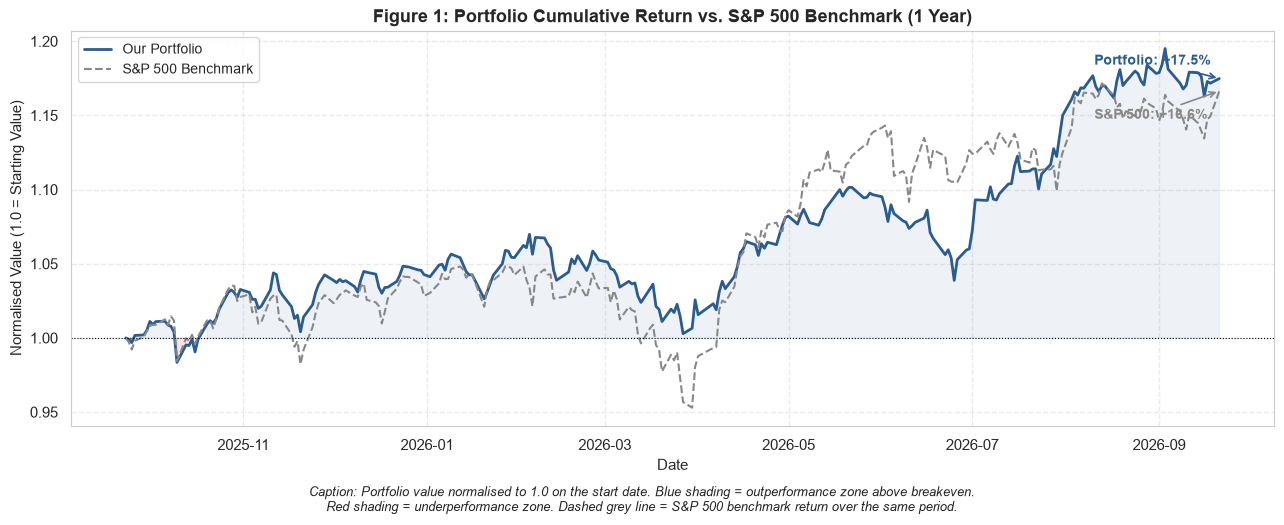


Portfolio 1-Year Return : +17.48%
S&P 500  1-Year Return  : +16.64%
Alpha (vs benchmark)    : +0.84%


In [8]:
# ── Benchmark: Fetch S&P 500 (ticker: ^GSPC) for the same period ─────────────
sp500_raw = yf.download('^GSPC', start=prices.index[0], end=prices.index[-1] + timedelta(days=1),
                         auto_adjust=True, progress=False)
sp500 = sp500_raw['Close'].squeeze()
sp500 = sp500.reindex(prices.index).ffill().dropna()

# ── Compute cumulative portfolio value over time ──────────────────────────────
# Weight each stock by its initial cost basis as a fraction of total portfolio
total_cost    = portfolio['Cost_Basis'].sum()
weights       = portfolio.set_index('Ticker')['Cost_Basis'] / total_cost  # fraction of portfolio per ticker

# Normalise prices to 1.0 on day 0, then weight-sum to get portfolio index
norm_prices   = prices / prices.iloc[0]                # each stock = 1.0 on start date
portfolio_idx = norm_prices.mul(weights, axis=1).sum(axis=1)  # weighted average

# Normalise S&P 500 to 1.0 on same start date
sp500_idx     = sp500 / sp500.iloc[0]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(portfolio_idx.index, portfolio_idx, color='#2b5c8f', linewidth=2,    label='Our Portfolio')
ax.plot(sp500_idx.index,     sp500_idx,     color='#888888', linewidth=1.5,
        linestyle='--', label='S&P 500 Benchmark')

ax.axhline(1.0, color='black', linewidth=0.8, linestyle=':')
ax.fill_between(portfolio_idx.index, 1.0, portfolio_idx,
                where=(portfolio_idx >= 1.0), alpha=0.08, color='#2b5c8f')
ax.fill_between(portfolio_idx.index, 1.0, portfolio_idx,
                where=(portfolio_idx < 1.0),  alpha=0.12, color='#d73027')

# Annotate final values
final_port  = portfolio_idx.iloc[-1]
final_sp500 = sp500_idx.iloc[-1]
ax.annotate(f'Portfolio: {(final_port-1)*100:+.1f}%',
            xy=(portfolio_idx.index[-1], final_port),
            xytext=(-90, 10), textcoords='offset points',
            fontsize=10, color='#2b5c8f', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2b5c8f', lw=1.2))
ax.annotate(f'S&P 500: {(final_sp500-1)*100:+.1f}%',
            xy=(sp500_idx.index[-1], final_sp500),
            xytext=(-90, -20), textcoords='offset points',
            fontsize=10, color='#888888', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1.2))

ax.set_title("Figure 1: Portfolio Cumulative Return vs. S&P 500 Benchmark (1 Year)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Normalised Value (1.0 = Starting Value)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.figtext(0.5, -0.04,
    "Caption: Portfolio value normalised to 1.0 on the start date. Blue shading = outperformance zone above breakeven.\n"
    "Red shading = underperformance zone. Dashed grey line = S&P 500 benchmark return over the same period.",
    ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

print(f"\nPortfolio 1-Year Return : {(final_port  - 1)*100:+.2f}%")
print(f"S&P 500  1-Year Return  : {(final_sp500 - 1)*100:+.2f}%")
print(f"Alpha (vs benchmark)    : {(final_port - final_sp500)*100:+.2f}%")

Weekly Return Stats:
  Mean  : +0.33%
  Std   : 1.58%
  Best  : +4.63%
  Worst : -2.74%
  Positive weeks: 28  |  Negative weeks: 24


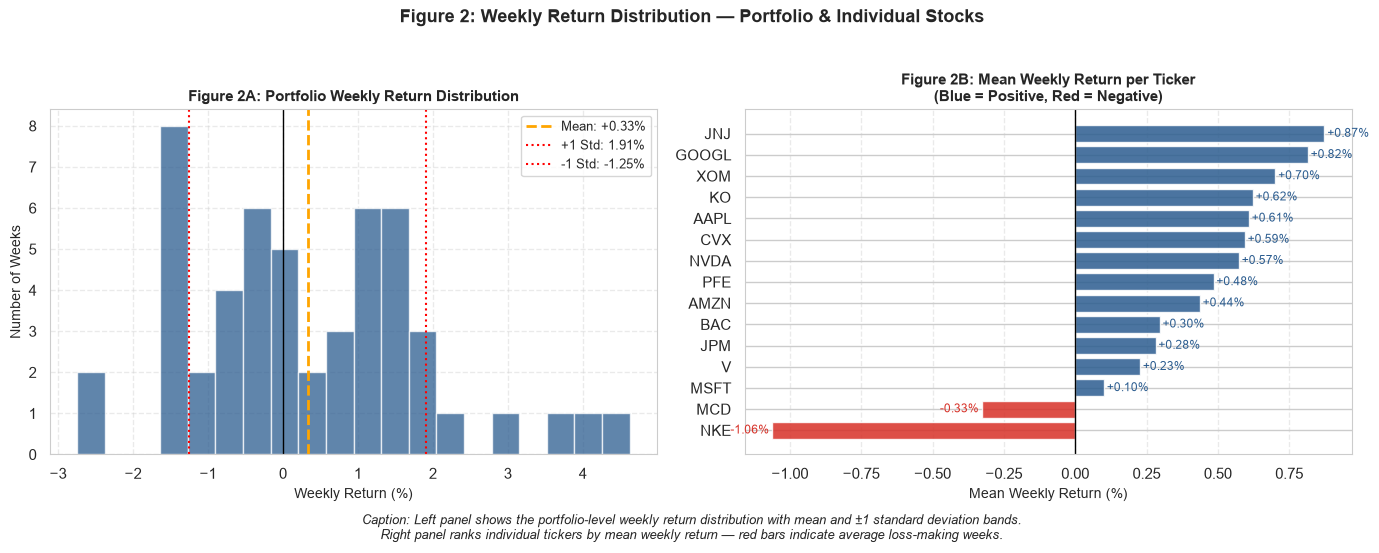

In [9]:
# ── Compute weekly returns (resample daily prices to weekly, last close) ──────
weekly_prices  = prices.resample('W').last()
weekly_returns = weekly_prices.pct_change().dropna() * 100   # as %

# Portfolio-level weekly return: cost-basis weighted average across tickers
weekly_portfolio_return = weekly_returns.mul(weights, axis=1).sum(axis=1)

mean_wr = weekly_portfolio_return.mean()
std_wr  = weekly_portfolio_return.std()
pos_weeks = (weekly_portfolio_return > 0).sum()
neg_weeks = (weekly_portfolio_return < 0).sum()

print(f"Weekly Return Stats:")
print(f"  Mean  : {mean_wr:+.2f}%")
print(f"  Std   : {std_wr:.2f}%")
print(f"  Best  : {weekly_portfolio_return.max():+.2f}%")
print(f"  Worst : {weekly_portfolio_return.min():+.2f}%")
print(f"  Positive weeks: {pos_weeks}  |  Negative weeks: {neg_weeks}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Portfolio-level weekly return histogram
axes[0].hist(weekly_portfolio_return, bins=20, color='#2b5c8f', alpha=0.75, edgecolor='white')
axes[0].axvline(mean_wr,   color='orange',  linewidth=2,   linestyle='--', label=f'Mean: {mean_wr:+.2f}%')
axes[0].axvline(mean_wr + std_wr, color='red', linewidth=1.5, linestyle=':', label=f'+1 Std: {mean_wr+std_wr:.2f}%')
axes[0].axvline(mean_wr - std_wr, color='red', linewidth=1.5, linestyle=':', label=f'-1 Std: {mean_wr-std_wr:.2f}%')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title("Figure 2A: Portfolio Weekly Return Distribution", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Weekly Return (%)", fontsize=10)
axes[0].set_ylabel("Number of Weeks", fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Right: Per-ticker mean weekly return ranked bar chart
mean_ticker_weekly = weekly_returns.mean().sort_values()
colors = ['#d73027' if v < 0 else '#2b5c8f' for v in mean_ticker_weekly]

axes[1].barh(mean_ticker_weekly.index, mean_ticker_weekly.values, color=colors, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=1)
for i, (ticker, val) in enumerate(mean_ticker_weekly.items()):
    axes[1].text(val + (0.01 if val >= 0 else -0.01), i,
                 f'{val:+.2f}%', va='center', ha='left' if val >= 0 else 'right',
                 fontsize=8.5, color='#d73027' if val < 0 else '#2b5c8f')
axes[1].set_title("Figure 2B: Mean Weekly Return per Ticker\n(Blue = Positive, Red = Negative)", 
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel("Mean Weekly Return (%)", fontsize=10)
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle("Figure 2: Weekly Return Distribution — Portfolio & Individual Stocks", 
             fontsize=13, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.04,
    "Caption: Left panel shows the portfolio-level weekly return distribution with mean and ±1 standard deviation bands.\n"
    "Right panel ranks individual tickers by mean weekly return — red bars indicate average loss-making weeks.",
    ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

=== SECTOR PERFORMANCE SUMMARY ===
    Sector  Total_Invested  Current_Value      Net_PnL  PnL_Pct
Technology         28850.0   53516.450348 24666.450348    85.50
   Finance         18800.0   32024.350510 13224.350510    70.34
    Energy          9225.0   13233.600082  4008.600082    43.45
Healthcare          7450.0   10858.100014  3408.100014    45.75
  Consumer         23150.0   25812.600784  2662.600784    11.50


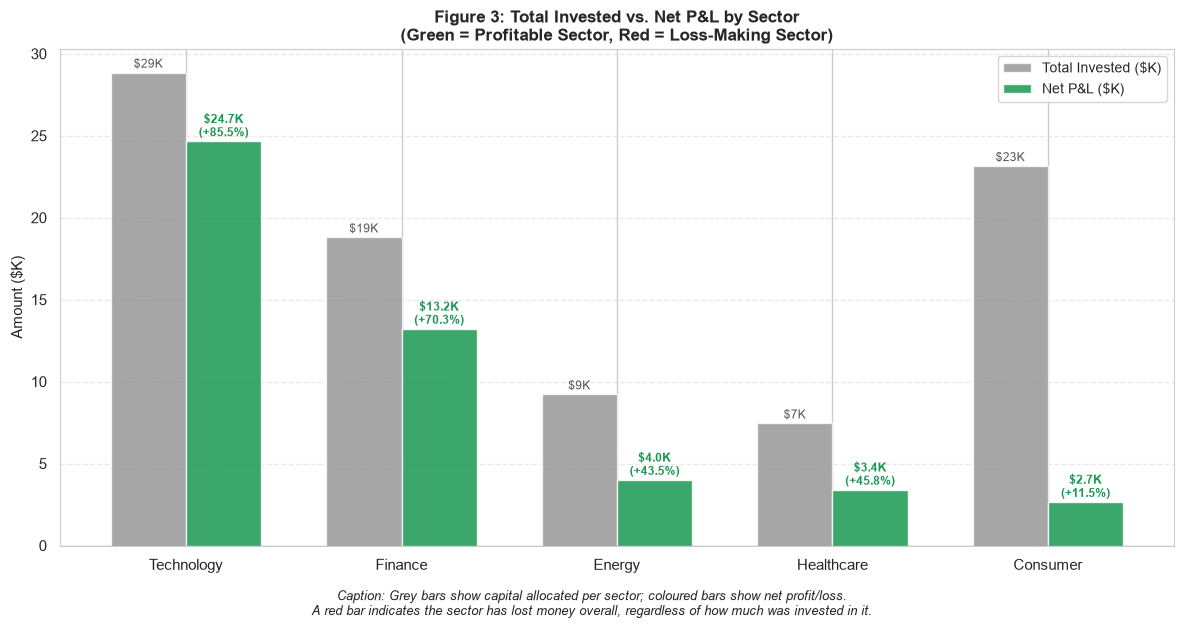

In [10]:
# ── Aggregate by sector ───────────────────────────────────────────────────────
sector_summary = portfolio.groupby('Sector').agg(
    Total_Invested  = ('Cost_Basis',    'sum'),
    Current_Value   = ('Market_Value',  'sum'),
    Net_PnL         = ('PnL_Dollar',    'sum')
).reset_index()

sector_summary['PnL_Pct'] = (sector_summary['Net_PnL'] / sector_summary['Total_Invested'] * 100).round(2)
sector_summary = sector_summary.sort_values('Net_PnL', ascending=False)

print("=== SECTOR PERFORMANCE SUMMARY ===")
print(sector_summary.to_string(index=False))

# ── Grouped Bar Chart ─────────────────────────────────────────────────────────
x      = range(len(sector_summary))
width  = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar([i - width/2 for i in x], sector_summary['Total_Invested']/1000, width=width,
               label='Total Invested ($K)', color='#888888', alpha=0.75)
bars2 = ax.bar([i + width/2 for i in x], sector_summary['Net_PnL']/1000, width=width,
               label='Net P&L ($K)',
               color=['#d73027' if v < 0 else '#1a9850' for v in sector_summary['Net_PnL']],
               alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(sector_summary['Sector'], fontsize=11)
ax.set_ylabel("Amount ($K)", fontsize=11)

# Value labels on each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"${bar.get_height():.0f}K", ha='center', fontsize=8.5, color='#555555')

for bar, pct in zip(bars2, sector_summary['PnL_Pct']):
    yval = bar.get_height()
    label_y = yval + 0.3 if yval >= 0 else yval - 1.2
    ax.text(bar.get_x() + bar.get_width()/2, label_y,
            f"${yval:.1f}K\n({pct:+.1f}%)", ha='center', fontsize=8.5,
            color='#1a9850' if yval >= 0 else '#d73027', fontweight='bold')

ax.set_title("Figure 3: Total Invested vs. Net P&L by Sector\n(Green = Profitable Sector, Red = Loss-Making Sector)",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.figtext(0.5, -0.04,
    "Caption: Grey bars show capital allocated per sector; coloured bars show net profit/loss.\n"
    "A red bar indicates the sector has lost money overall, regardless of how much was invested in it.",
    ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

--- Top 5 Most Correlated (Concentrated Risk) ---
Stock A Stock B  Correlation
    CVX     XOM     0.841394
    BAC     JPM     0.746293
   AMZN   GOOGL     0.531797
     KO     MCD     0.487678
   AMZN    MSFT     0.388368

--- Top 5 Least Correlated (Best Diversification) ---
Stock A Stock B  Correlation
    XOM     NKE          NaN
    XOM    NVDA          NaN
    XOM     PFE          NaN
    XOM       V          NaN
    XOM     XOM          NaN


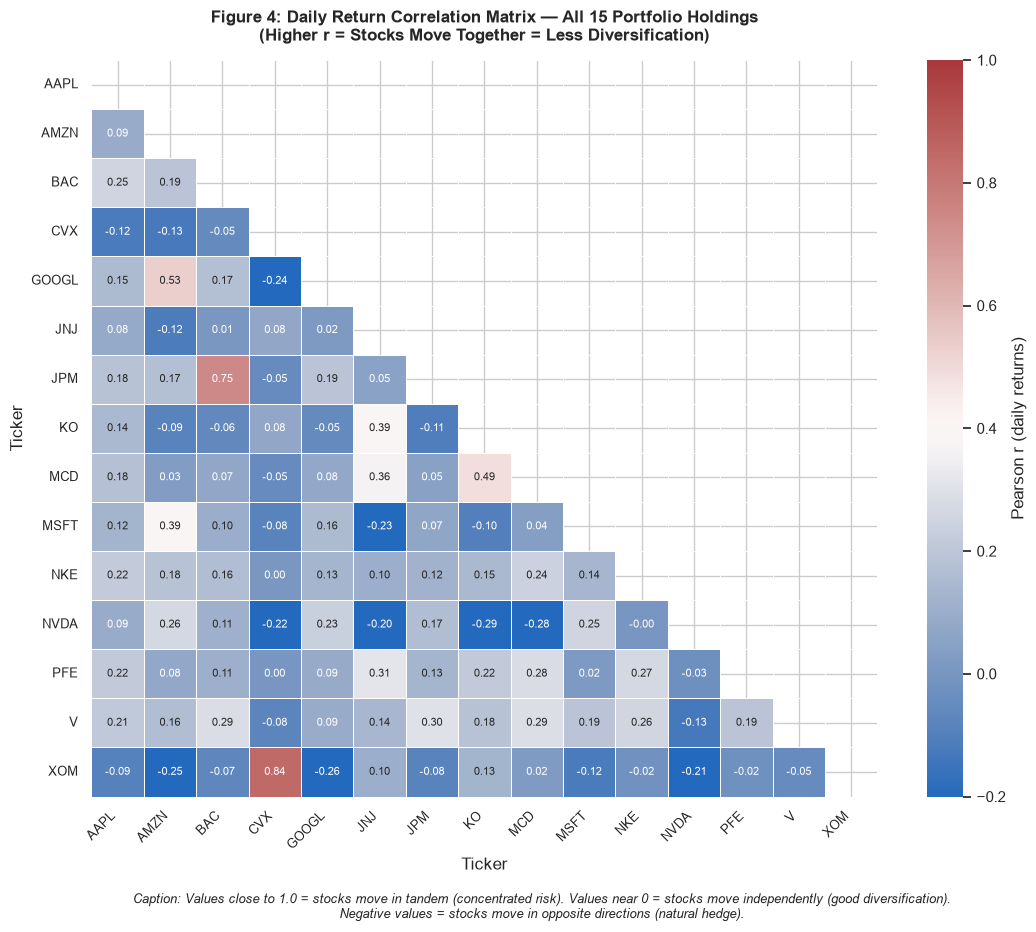

In [14]:
# ── Pearson correlation matrix of daily returns ───────────────────────────────
corr_matrix = daily_returns.corr()

# Fix: give index and columns distinct names before stacking
corr_copy = corr_matrix.copy()
corr_copy.index.name   = 'Stock_A'
corr_copy.columns.name = 'Stock_B'

corr_pairs = (corr_copy
              .where(np.triu(np.ones(corr_copy.shape), k=1).astype(bool))
              .stack()
              .reset_index())
corr_pairs.columns = ['Stock A', 'Stock B', 'Correlation']
corr_pairs = corr_pairs.sort_values('Correlation', ascending=False)

print("--- Top 5 Most Correlated (Concentrated Risk) ---")
print(corr_pairs.head(5).to_string(index=False))
print("\n--- Top 5 Least Correlated (Best Diversification) ---")
print(corr_pairs.tail(5).to_string(index=False))

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask   = mask,
    annot  = True,
    fmt    = ".2f",
    cmap   = "vlag",
    vmin   = -0.2,
    vmax   = 1.0,
    linewidths = 0.5,
    annot_kws  = {"size": 8},
    cbar_kws   = {"label": "Pearson r (daily returns)"},
    ax     = ax
)

ax.set_title("Figure 4: Daily Return Correlation Matrix — All 15 Portfolio Holdings\n"
             "(Higher r = Stocks Move Together = Less Diversification)",
             fontsize=12, fontweight='bold', pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.figtext(0.5, -0.03,
    "Caption: Values close to 1.0 = stocks move in tandem (concentrated risk). "
    "Values near 0 = stocks move independently (good diversification).\n"
    "Negative values = stocks move in opposite directions (natural hedge).",
    ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

=== ANNUALISED VOLATILITY RANKING (%) ===
Ticker
MCD      18.62
KO       18.79
JNJ      19.02
BAC      22.00
V        22.00
JPM      22.22
PFE      23.36
CVX      23.95
AAPL     24.59
XOM      26.20
GOOGL    31.60
MSFT     32.66
AMZN     34.45
NKE      36.48
NVDA     37.91


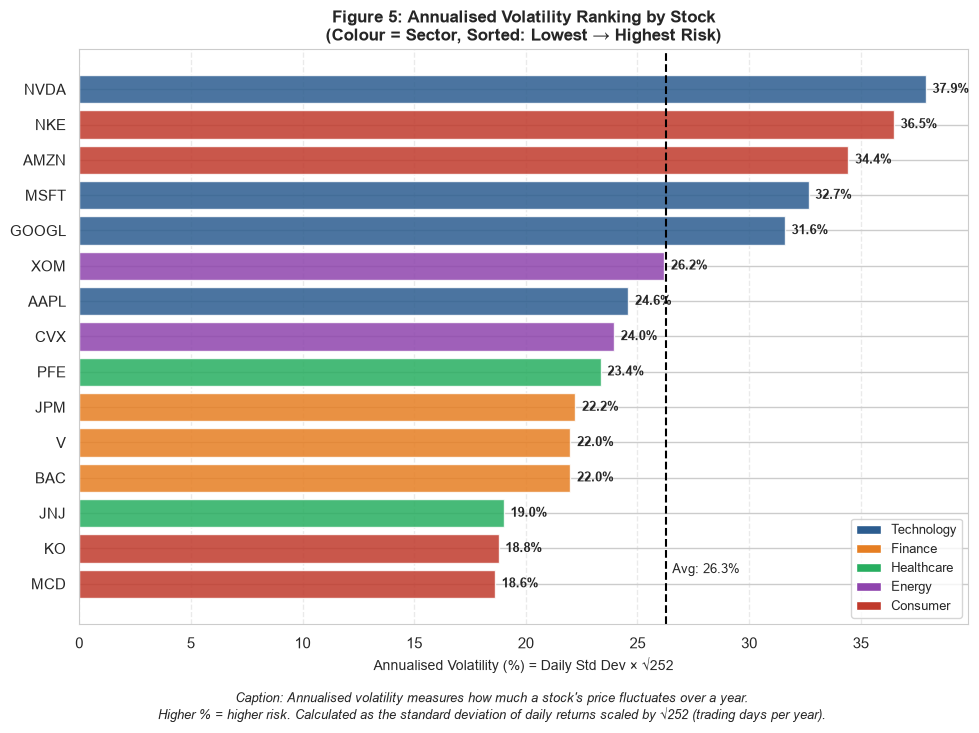

In [16]:
# ── Annualised volatility = daily std × √252 trading days ────────────────────
annual_vol = (daily_returns.std() * np.sqrt(252)).sort_values()

print("=== ANNUALISED VOLATILITY RANKING (%) ===")
print(annual_vol.round(2).to_string())

# ── Horizontal bar chart (sorted lowest → highest) ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = []
for ticker in annual_vol.index:
    sector = portfolio.set_index('Ticker').loc[ticker, 'Sector']
    sector_colors = {
        'Technology': '#2b5c8f',
        'Finance':    '#e67e22',
        'Healthcare': '#27ae60',
        'Energy':     '#8e44ad',
        'Consumer':   '#c0392b'
    }
    colors.append(sector_colors[sector])

bars = ax.barh(annual_vol.index, annual_vol.values, color=colors, alpha=0.85, edgecolor='white')

# Annotate each bar with the exact % value
for bar, val in zip(bars, annual_vol.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# Legend for sector colours
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2b5c8f', label='Technology'),
                   Patch(facecolor='#e67e22', label='Finance'),
                   Patch(facecolor='#27ae60', label='Healthcare'),
                   Patch(facecolor='#8e44ad', label='Energy'),
                   Patch(facecolor='#c0392b', label='Consumer')]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

ax.set_title("Figure 5: Annualised Volatility Ranking by Stock\n(Colour = Sector, Sorted: Lowest → Highest Risk)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Annualised Volatility (%) = Daily Std Dev × √252", fontsize=10)
ax.axvline(annual_vol.mean(), color='black', linewidth=1.5, linestyle='--',
           label=f'Portfolio Avg: {annual_vol.mean():.1f}%')
ax.text(annual_vol.mean() + 0.3, 0.3, f'Avg: {annual_vol.mean():.1f}%', fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.figtext(0.5, -0.04,
    "Caption: Annualised volatility measures how much a stock's price fluctuates over a year.\n"
    "Higher % = higher risk. Calculated as the standard deviation of daily returns scaled by √252 (trading days per year).",
    ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()